In [4]:
import matplotlib.pyplot as plt
import numpy as np

import wandb


In [5]:
# Initialize wandb API
api = wandb.Api(timeout=60)

# # Get the sweep
# sweep = api.sweep("saul0/fedHAR/5nf0ajkn")

# # Get all runs from the sweep
# runs = sweep.runs

# # Print parameters for each run
# for run in runs:
#     print(f"Run: {run.name} (ID: {run.id})")
#     print(f"Config: {run.config}")
#     print("-" * 80)

# Plots for RQ4 (cost model)

In [33]:
# Collect communication cost data from the sweep
sweep_id = "ICDCS/FedHAR/9uw01ajn"

print(f"Fetching sweep: {sweep_id}")
sweep = api.sweep(sweep_id)
runs = sweep.runs

# Dictionary to store run data
run_comm_costs = {}

for run in runs:
    print(f"\nProcessing run: {run.name}")

    # Initialize data structures
    rounds = []
    total_costs_per_round = []  # Sum across all clusters per round
    cluster_costs = {}  # {cluster_id: [costs per round]}
    cluster_model_sizes = {}  # {cluster_id: set of unique model sizes in bits}

    for row in run.scan_history():
        round_num = row.get("round", None)
        if round_num is None:
            continue

        rounds.append(round_num)
        round_total = 0

        # Collect costs and model sizes for each cluster
        for i in range(8):  # Adjust range based on number of clusters
            cost_key = f"CommCost/Group_{i}/Total/Combined"
            cost_val = row.get(cost_key, None)

            if cost_val is not None and cost_val == cost_val:  # Check for not None and not NaN
                round_total += cost_val

                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(cost_val)
            else:
                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(0)

            # Collect model size in bits for each cluster
            model_size_key = f"CommCost/Group_{i}/ModelSize/Bits"
            model_size_val = row.get(model_size_key, None)
            if model_size_val is not None and model_size_val == model_size_val:
                if i not in cluster_model_sizes:
                    cluster_model_sizes[i] = set()
                cluster_model_sizes[i].add(model_size_val)

        total_costs_per_round.append(round_total)

    # Calculate average pruning ratio for this run
    pruning_ratios = []
    for cluster_id, sizes in cluster_model_sizes.items():
        unique_sizes = sorted(sizes)
        # Ratio of smaller to larger model size
        ratio = unique_sizes[0] / unique_sizes[-1]
        pruning_ratios.append(ratio)
        print(f"  Cluster {cluster_id}: sizes={unique_sizes}, ratio={ratio:.4f}")

    avg_ratio = np.mean(pruning_ratios)
    avg_pruning_ratio = 1 - avg_ratio
    print(f"  Average pruning ratio: {avg_pruning_ratio:.4f}")

    # Store the data
    run_comm_costs[run.name] = {
        "rounds": rounds,
        "total_costs": total_costs_per_round,
        "cluster_costs": cluster_costs,
        "cluster_model_sizes": {k: sorted(v) for k, v in cluster_model_sizes.items()},
        "avg_pruning_ratio": avg_pruning_ratio,
    }

    print(f"  Collected {len(rounds)} rounds")
    print(f"  Total clusters: {len(cluster_costs)}")

print(f"\nCollected data from {len(run_comm_costs)} runs")

Fetching sweep: ICDCS/FedHAR/9uw01ajn

Processing run: 4-clust

Processing run: 4-clust
  Cluster 3: sizes=[321408, 487648], ratio=0.6591
  Cluster 0: sizes=[321408, 487648], ratio=0.6591
  Cluster 1: sizes=[321408, 487648], ratio=0.6591
  Cluster 2: sizes=[321408, 487648], ratio=0.6591
  Average pruning ratio: 0.3409
  Collected 1324 rounds
  Total clusters: 8

Processing run: 8-clust
  Cluster 3: sizes=[321408, 487648], ratio=0.6591
  Cluster 0: sizes=[321408, 487648], ratio=0.6591
  Cluster 1: sizes=[321408, 487648], ratio=0.6591
  Cluster 2: sizes=[321408, 487648], ratio=0.6591
  Average pruning ratio: 0.3409
  Collected 1324 rounds
  Total clusters: 8

Processing run: 8-clust
  Cluster 4: sizes=[326176, 487648], ratio=0.6689
  Cluster 0: sizes=[321408, 487648], ratio=0.6591
  Cluster 3: sizes=[321408, 487648], ratio=0.6591
  Cluster 1: sizes=[321408, 487648], ratio=0.6591
  Cluster 2: sizes=[321408, 487648], ratio=0.6591
  Cluster 5: sizes=[321408, 487648], ratio=0.6591
  Cluster 

In [56]:
# parameters
total_clients = 120
num_clients = 10
z_card = np.array([57, 63], dtype=float)
# size in bits
model_size = 487648
prune_ratio = 0.3
# need to see based on the votes
p = [0.1, 0.1]

# vectorized computations with numpy
s_z = (z_card / total_clients) * num_clients
extr_prob = np.divide(s_z, z_card, out=np.zeros_like(s_z))

# compute p_z and protect against non-positive probabilities
p_z = 1.0 - (1.0 - extr_prob * p) ** z_card

t_before = 1.0 / p_z
q_z = 1.0 - prune_ratio


def cost_model(t):
    return 2 * s_z * model_size * (np.minimum(t_before, t) + q_z * np.maximum(0, t - t_before))


In [57]:
t_before

array([2.63607826, 2.44054546])

Testing cost_model function...
t_before values: [2.63607826 2.44054546]
s_z values: [4.75 5.25]
model_size: 487648

Test outputs:
  t=0: cost=[0. 0.]
  t=50: cost=[1.65806573e+08 1.82959540e+08]
  t=100: cost=[3.27949533e+08 3.62170180e+08]
  t=150: cost=[4.90092493e+08 5.41380820e+08]
  t=200: cost=[6.52235453e+08 7.20591460e+08]


Testing cost_model function...
t_before values: [2.63607826 2.44054546]
s_z values: [4.75 5.25]
model_size: 487648

Test outputs:
  t=0: cost=[0. 0.]
  t=50: cost=[1.65806573e+08 1.82959540e+08]
  t=100: cost=[3.27949533e+08 3.62170180e+08]
  t=150: cost=[4.90092493e+08 5.41380820e+08]
  t=200: cost=[6.52235453e+08 7.20591460e+08]


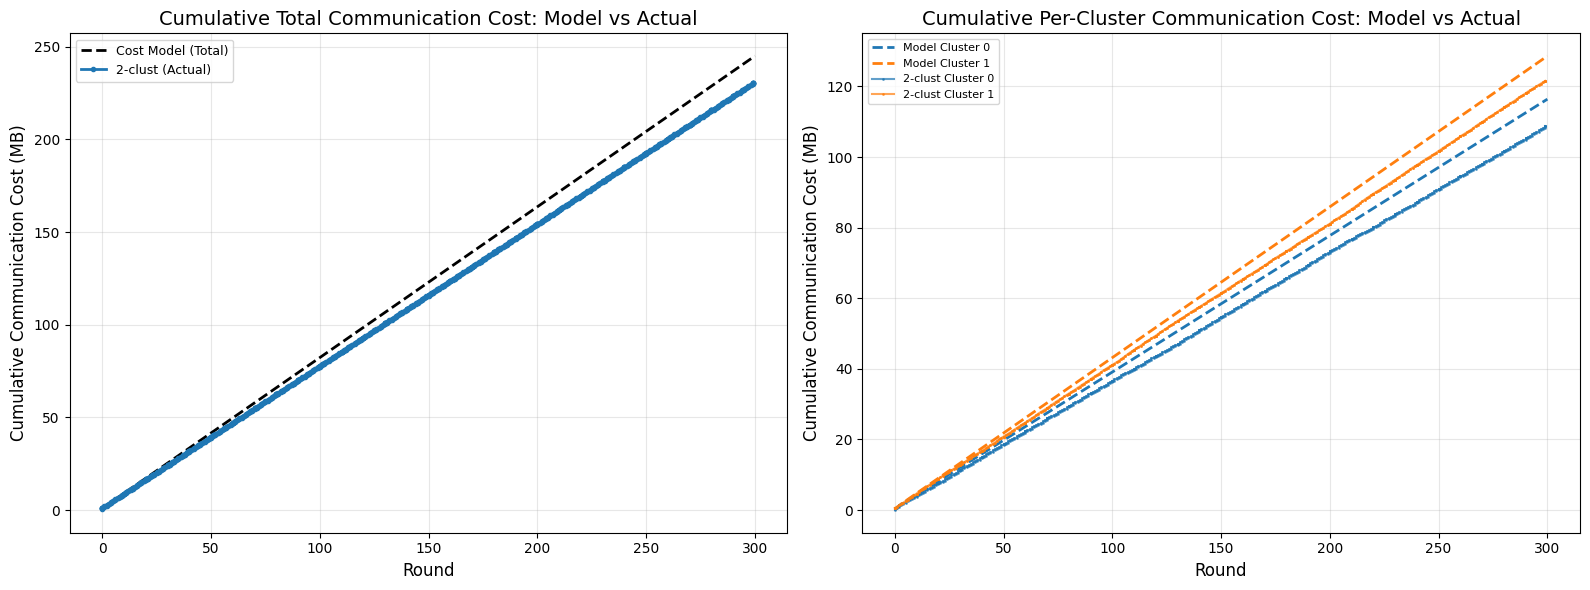


Plot generated successfully!
t_before thresholds: [2.63607826 2.44054546]


In [58]:
# Test and plot the cost model over time
print("Testing cost_model function...")
print(f"t_before values: {t_before}")
print(f"s_z values: {s_z}")
print(f"model_size: {model_size}")

# Test with a few sample values
test_times = [0, 50, 100, 150, 200]
print("\nTest outputs:")
for t in test_times:
    try:
        cost = cost_model(t)
        print(f"  t={t}: cost={cost}")
    except Exception as e:
        print(f"  t={t}: ERROR - {e}")

# Create time array for plotting the model
t_values = np.linspace(0, 300, 300)
model_costs = np.array([cost_model(t) for t in t_values])

# Convert model costs to MB (model already returns cumulative values)
model_costs_mb = model_costs / (8 * 1024 * 1024)

# Create figure with subplots: one for total cost, one for per-cluster costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Communication Cost (CUMULATIVE)
ax1.set_xlabel("Round", fontsize=12)
ax1.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax1.set_title("Cumulative Total Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative total cost (sum across groups) - already cumulative from model
total_model_cost = model_costs_mb.sum(axis=1)
ax1.plot(t_values, total_model_cost, label="Cost Model (Total)", linewidth=2, linestyle="--", color="black")

# Plot actual run total costs (CUMULATIVE)
for run_name, run_data in run_comm_costs.items():
    if "2-clust" not in run_name:
        continue
    rounds = run_data["rounds"]
    total_costs = np.cumsum(run_data["total_costs"]) / (8 * 1024 * 1024)  # Cumulative and convert to MB
    ax1.plot(rounds, total_costs, label=f"{run_name} (Actual)", linewidth=2, marker="o", markersize=3)

ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Per-Cluster Communication Cost (CUMULATIVE)
ax2.set_xlabel("Round", fontsize=12)
ax2.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax2.set_title("Cumulative Per-Cluster Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative costs per group - already cumulative from model
for i in range(len(z_card)):
    ax2.plot(t_values, model_costs_mb[:, i], label=f"Model Cluster {i}", linewidth=2, linestyle="--")

# Plot actual cluster costs from runs (CUMULATIVE)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for run_name, run_data in run_comm_costs.items():
    if "2-clust" not in run_name:
        continue
    rounds = run_data["rounds"]
    cluster_costs = run_data["cluster_costs"]

    for cluster_id, costs in cluster_costs.items():
        cumulative_costs = np.cumsum(costs) / (8 * 1024 * 1024)  # Cumulative and convert to MB
        if (cumulative_costs == 0).all():
            continue
        ax2.plot(
            rounds,
            cumulative_costs,
            label=f"{run_name} Cluster {cluster_id}",
            linewidth=1.5,
            marker=".",
            markersize=2,
            color=colors[cluster_id % 10],
            alpha=0.7,
        )

ax2.legend(loc="best", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPlot generated successfully!")
print(f"t_before thresholds: {t_before}")

# RQ3 answer

In [6]:
runs_history_cache = {}

In [ ]:
# Process multiple sweeps and compute metrics for each run
# Define three separate lists for each dataset

# FEMNIST sweeps
sweep_ids_femnist = ["ICDCS/FEMNIST/hgr1nvs2", "ICDCS/FEMNIST/mz7vf3nw", "ICDCS/FEMNIST/r4elav3k"]

# CIFAR10 sweeps
sweep_ids_cifar = ["ICDCS/FedCIFAR10/f89m606t", "ICDCS/FedCIFAR10/0c4bz5ui", "ICDCS/FedCIFAR10/wj72wuag"]

# HAR sweeps
sweep_ids_har = ["ICDCS/FedHAR/x4lfn7y2", "ICDCS/FedHAR/pbs8l2ut", "ICDCS/FedHAR/09gwsk62"]

# Combine all sweeps with dataset labels
all_datasets = [("FEMNIST", sweep_ids_femnist), ("CIFAR10", sweep_ids_cifar), ("HAR", sweep_ids_har)]

metric_name = "Server/Test/Acc"

# Dictionary to store results by dataset
results_by_dataset = {}

print("=" * 80)
print("Processing sweeps for all datasets")
print(f"Metric: {metric_name}")
print("=" * 80)

for dataset_name, sweep_ids in all_datasets:
    print(f"\n{'=' * 80}")
    print(f"Dataset: {dataset_name}")
    print(f"{'=' * 80}")

    results_dict = {}

    for sweep_id in sweep_ids:
        print(f"\nSweep: {sweep_id}")
        print("-" * 80)

        # Get the sweep
        sweep = api.sweep(sweep_id)
        sweep_runs = sweep.runs

        for run in sweep_runs:
            # Get prune_percent from config
            print(run.config)
            prune_percent = run.config["train_args"]["prune_percent"]

            # Compute the metric (last value)
            cache_key = (run.id, metric_name)
            cache_key_cost = (run.id, "total_upload_cost_sum")
            if cache_key in runs_history_cache:
                metric_data = runs_history_cache[cache_key]
                total_cost_mb = runs_history_cache[cache_key_cost]
            else:
                metric_data = []
                total_cost = 0
                for row in run.scan_history():
                    val = row.get(metric_name, None)
                    if val is not None and val == val:  # Check for not None and not NaN
                        metric_data.append(val)
                    # Sum all CommCost/Group_{i}/Total/Upload metrics for this row
                    for key, val in row.items():
                        if "CommCost/Group_" in key and "/Total/Combined" in key:
                            if val is not None and val == val:
                                total_cost += val

                runs_history_cache[cache_key_cost] = total_cost
                runs_history_cache[cache_key] = metric_data
                # Convert to MB
                total_cost_mb = total_cost / (8 * 1024 * 1024) if total_cost is not None else None

            server_accuracy = metric_data[-1] if metric_data else None

            # Store in dictionary
            results_dict[run.name] = {
                "prune_percent": prune_percent,
                "server_accuracy": server_accuracy,
                "total_cost_mb": total_cost_mb,
            }

            # Print the triplet
            print(f"Run: {run.name}")
            print(
                f"  <prune_percent={prune_percent}, {metric_name}={server_accuracy:.4f}, total_cost={total_cost_mb:.2f} MB>"
            )
            print()

    print(f"\n{dataset_name} - Results stored")
    print(f"Total runs processed: {len(results_dict)}")

    # Store results for this dataset
    results_by_dataset[dataset_name] = results_dict

print("\n" + "=" * 80)
print("All datasets processed")
print(f"Datasets: {list(results_by_dataset.keys())}")
print("=" * 80)

Processing sweeps for all datasets
Metric: Server/Test/Acc

Dataset: FEMNIST

Sweep: ICDCS/FEMNIST/hgr1nvs2
--------------------------------------------------------------------------------
{'train_args': {'pruning': 'proposal', 'preference': -200, 'prune_percent': 0.25, 'ssl_coefficient': 0.0001, 'accuracy_threshold': 0.4, 'consolidation_percentage': 0.25}, 'device_args': {'gpu_id': 0}}
Run: 4-clust-4
  <prune_percent=0.25, Server/Test/Acc=0.1438, total_cost=1070685334656.00 MB>

{'train_args': {'pruning': 'proposal', 'preference': -200, 'prune_percent': 0.2, 'ssl_coefficient': 0.0001, 'accuracy_threshold': 0.4, 'consolidation_percentage': 0.2}, 'device_args': {'gpu_id': 0}}
Run: 4-clust-3
  <prune_percent=0.2, Server/Test/Acc=0.1540, total_cost=1338327458112.00 MB>

{'train_args': {'pruning': 'proposal', 'preference': -200, 'prune_percent': 0.15, 'ssl_coefficient': 0.0001, 'accuracy_threshold': 0.4, 'consolidation_percentage': 0.15}, 'device_args': {'gpu_id': 0}}
Run: 4-clust-2
  <pru


FEMNIST: Plotted 3 cluster configurations:
  16-clust: 4 runs
  4-clust: 4 runs
  8-clust: 4 runs

CIFAR10: Plotted 3 cluster configurations:
  2-clust: 4 runs
  4-clust: 5 runs
  8-clust: 4 runs

HAR: Plotted 3 cluster configurations:
  2-clust: 5 runs
  4-clust: 5 runs
  8-clust: 5 runs


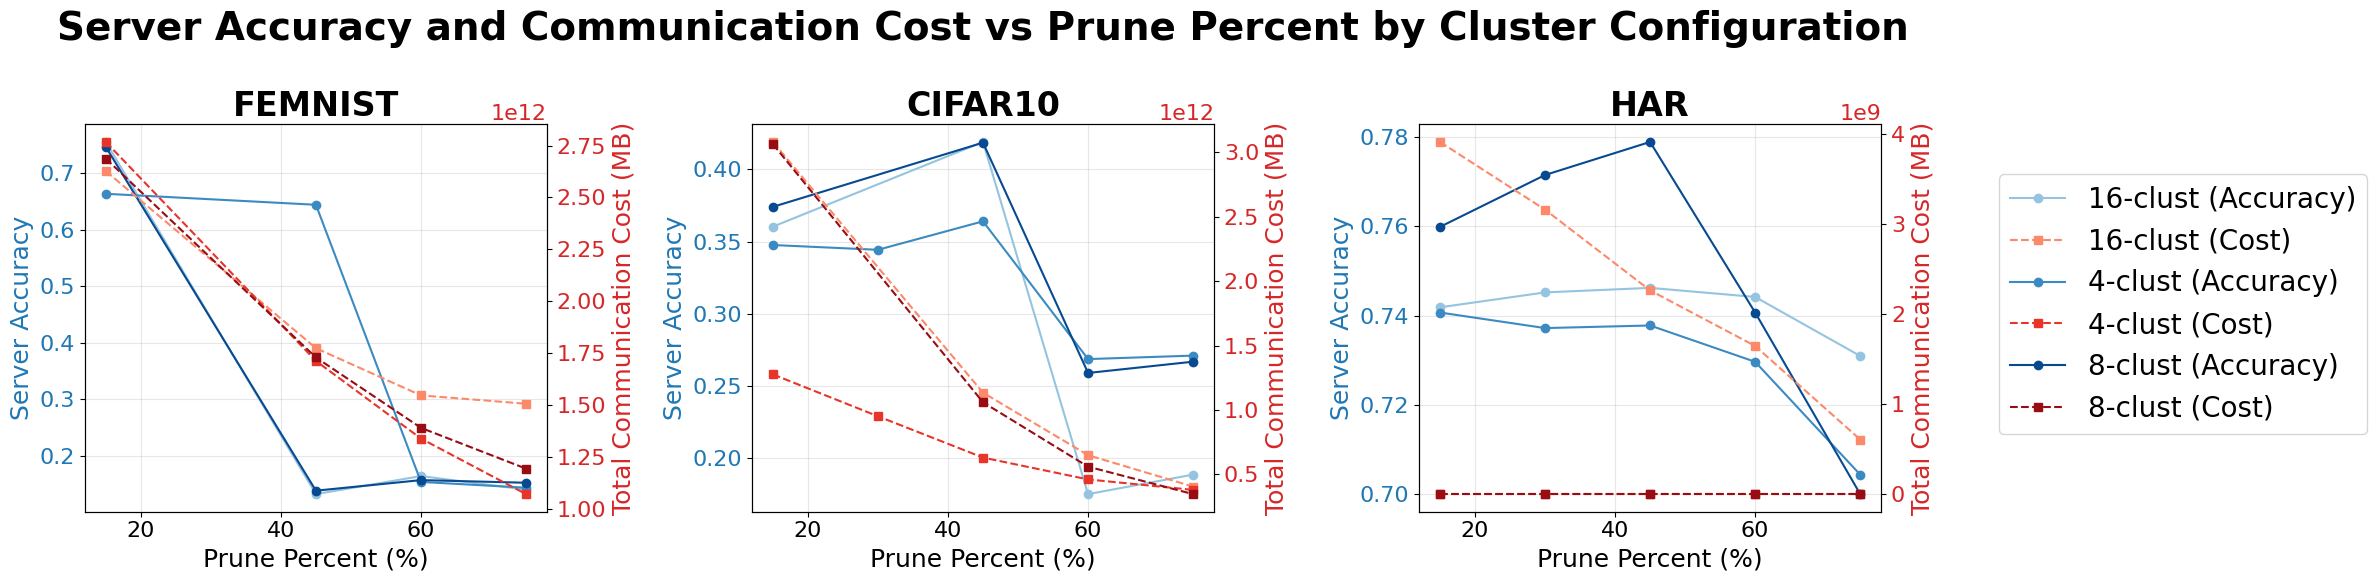


Created 3-subplot figure with shared legend


In [ ]:
# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 17,
        "figure.titlesize": 22,
        "legend.title_fontsize": 17,
    }
)

# Group runs by cluster prefix for each dataset and create 3 subplots
from collections import defaultdict

# Create figure with 3 subplots (one per dataset)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Store all line objects and labels for shared legend
all_lines = []
all_labels = []

# Process each dataset
for ax_idx, (dataset_name, results_dict) in enumerate(results_by_dataset.items()):
    ax1 = axes[ax_idx]

    # Group runs by cluster prefix
    cluster_runs = defaultdict(list)

    for run_name, data in results_dict.items():
        # Extract the cluster prefix (e.g., "2_clust" from "2_clust_random_0.1")
        # Assuming format: <N>_clust<something>
        if "clust" in run_name:
            prefix = run_name.split("clust")[0] + "clust"
            cluster_runs[prefix].append(
                {
                    "run_name": run_name,
                    "prune_percent": data["prune_percent"],
                    "server_accuracy": data["server_accuracy"],
                    "total_cost_mb": data["total_cost_mb"],
                }
            )

    # Sort each cluster's runs by prune_percent
    for prefix in cluster_runs:
        cluster_runs[prefix].sort(key=lambda x: x["prune_percent"])

    # Left y-axis for accuracy
    ax1.set_xlabel("Prune Percent (%)", fontsize=18)
    ax1.set_ylabel("Server Accuracy", color="tab:blue", fontsize=18)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Right y-axis for communication cost
    ax2 = ax1.twinx()
    ax2.set_ylabel("Total Communication Cost (MB)", color="tab:red", fontsize=18)
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # Color schemes
    accuracy_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cluster_runs)))
    cost_colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(cluster_runs)))

    # Plot each cluster run
    for idx, (prefix, runs) in enumerate(sorted(cluster_runs.items())):
        prune_percents = [round(r["prune_percent"] * 3 * 100) for r in runs]  # Convert to percentage
        accuracies = [r["server_accuracy"] for r in runs]
        costs = [r["total_cost_mb"] for r in runs]

        # Plot accuracy on left y-axis
        line1 = ax1.plot(
            prune_percents,
            accuracies,
            marker="o",
            linestyle="-",
            color=accuracy_colors[idx],
            label=f"{prefix} (Accuracy)",
        )[0]

        # Plot communication cost on right y-axis
        line2 = ax2.plot(
            prune_percents, costs, marker="s", linestyle="--", color=cost_colors[idx], label=f"{prefix} (Cost)"
        )[0]

        # Collect lines and labels for shared legend (only from first subplot)
        if ax_idx == 0:
            all_lines.extend([line1, line2])
            all_labels.extend([f"{prefix} (Accuracy)", f"{prefix} (Cost)"])

    # Add grid
    ax1.grid(True, alpha=0.3)

    # Set subplot title
    ax1.set_title(f"{dataset_name}", fontsize=24, fontweight="bold")

    print(f"\n{dataset_name}: Plotted {len(cluster_runs)} cluster configurations:")
    for prefix, runs in sorted(cluster_runs.items()):
        print(f"  {prefix}: {len(runs)} runs")

# Create a shared legend below all subplots
fig.legend(all_lines, all_labels, loc="lower center", fontsize=20, bbox_to_anchor=(1.1, 0.25))

# Overall title
fig.suptitle(
    "Server Accuracy and Communication Cost vs Prune Percent by Cluster Configuration",
    fontsize=28,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with shared legend")

In [27]:
# Add consensus_percentage to each run in results_dict
for run_name in results_dict:
    results_dict[run_name]["consensus_percentage"] = 0.5

print(f"Added consensus_percentage=0.5 to {len(results_dict)} runs")

Added consensus_percentage=0.5 to 15 runs


# RQ2: consensus percentage

In [ ]:
runs_history_cache = {}
results_by_dataset_rq2 = {"FEMNIST": {}, "CIFAR10": {}, "HAR": {}}

In [16]:
# Process multiple sweeps and compute metrics for each run

# Define sweep IDs for each dataset
sweep_ids_by_dataset = {
    "FEMNIST": ["ICDCS/FEMNIST/6wug73uc"],  # Add your FEMNIST sweep IDs here
    "CIFAR10": ["ICDCS/FedCIFAR10/5dc8bowz"],
    "HAR": ["ICDCS/FedHAR/b74scpxu"],  # Add your HAR sweep IDs here
}

# Metric to extract (can be changed)
metric_name = "Server/Test/Acc"

print("=" * 80)
print("Processing sweeps for all datasets (RQ2)")
print(f"Metric: {metric_name}")
print("=" * 80)

for dataset_name, sweep_ids in sweep_ids_by_dataset.items():
    print(f"\n{'=' * 80}")
    print(f"Dataset: {dataset_name}")
    print(f"{'=' * 80}")

    for sweep_id in sweep_ids:
        print(f"\nSweep: {sweep_id}")
        print("-" * 80)

        # Get the sweep
        sweep = api.sweep(sweep_id)
        sweep_runs = sweep.runs

        for run in sweep_runs:
            # Get consensus_percent from config
            print(run.config)
            consensus_percent = run.config["train_args"]["consensus_percentage"]

            # Compute the metric (last value)
            cache_key = (run.id, metric_name)
            if cache_key in runs_history_cache:
                metric_data = runs_history_cache[cache_key]
            else:
                metric_data = []
                for row in run.history():
                    val = row.get(metric_name, None)
                    if val is not None and val == val:  # Check for not None and not NaN
                        metric_data.append(val)
                runs_history_cache[cache_key] = metric_data

            server_accuracy = metric_data[-1] if metric_data else None

            # Compute total communication cost
            # For FedAvg, use download metric; for others, sum group uploads
            if "FedAvg" in run.name:
                cost_metric = "CommCost/Total/Download"
                cache_key = (run.id, cost_metric, "total_cost")
                if cache_key in runs_history_cache:
                    total_cost = runs_history_cache[cache_key]
                else:
                    total_cost = 0
                    for row in run.history():
                        val = row.get(cost_metric, None)
                        if val is not None and val == val:
                            total_cost += val
                    runs_history_cache[cache_key] = total_cost
            else:
                cache_key = (run.id, "total_upload_cost_sum")
                if cache_key in runs_history_cache:
                    total_cost = runs_history_cache[cache_key]
                else:
                    total_cost = 0
                    for row in run.history():
                        # Sum all CommCost/Group_{i}/Total/Upload metrics for this row
                        for key, val in row.items():
                            for i in range(8):
                                if key == f"CommCost/Group_{i}/Total/Combined":
                                    if val is not None and val == val:
                                        total_cost += val
                    runs_history_cache[cache_key] = total_cost

            # Convert to MB
            total_cost_mb = total_cost / (8 * 1024 * 1024) if total_cost is not None else None

            # Detect pruning rounds by monitoring model size decreases
            pruning_events = []  # List of (round, group_id, model_size_before, model_size_after)

            # Track model size for each group across rounds
            group_model_sizes = {}  # {group_id: [(round, model_size), ...]}

            for row in run.history():
                round_num = row.get("round", None)
                if round_num is None:
                    continue

                # Check all group model sizes
                for i in range(8):
                    metric_key = f"CommCost/Group_{i}/ModelSize/Parameters"
                    if metric_key in row:
                        model_size = row.get(metric_key, None)
                        if model_size is not None and model_size == model_size:  # Check for not None and not NaN
                            if i not in group_model_sizes:
                                group_model_sizes[i] = []

                            # Check if this is a decrease from previous round
                            if group_model_sizes[i]:
                                prev_round, prev_size = group_model_sizes[i][-1]
                                if model_size < prev_size:
                                    # Pruning detected!
                                    pruning_events.append(
                                        {
                                            "round": round_num,
                                            "group_id": i,
                                            "model_size_before": prev_size,
                                            "model_size_after": model_size,
                                        }
                                    )

                            group_model_sizes[i].append((round_num, model_size))

            # Store in dictionary for this dataset
            results_by_dataset_rq2[dataset_name][run.name] = {
                "consensus_percentage": consensus_percent,
                "server_accuracy": server_accuracy,
                "total_cost_mb": total_cost_mb,
                "pruning_events": pruning_events,
            }

            # Print the triplet
            print(f"Run: {run.name}")
            print(
                f"  <consensus_percentage={consensus_percent}, {metric_name}={server_accuracy:.4f}, total_cost={total_cost_mb:.2f} MB>"
            )

            # Print pruning events
            if pruning_events:
                print(f"  Pruning events detected: {len(pruning_events)}")
                for event in pruning_events:
                    print(
                        f"    Round {event['round']}: Group {event['group_id']} pruned "
                        f"({event['model_size_before']:.0f} -> {event['model_size_after']:.0f} parameters)"
                    )
            else:
                print("  No pruning events detected")
            print()

    print(f"\n{dataset_name} - Results stored")
    print(f"Total runs processed: {len(results_by_dataset_rq2[dataset_name])}")

print("\n" + "=" * 80)
print("All datasets processed")
print(f"Datasets: {list(results_by_dataset_rq2.keys())}")
print("=" * 80)

Processing sweeps for all datasets (RQ2)
Metric: Server/Test/Acc

Dataset: FEMNIST

Sweep: ICDCS/FEMNIST/6wug73uc
--------------------------------------------------------------------------------
{'train_args': {'pruning': 'proposal', 'preference': -43, 'prune_percent': 0.1, 'ssl_coefficient': 0.0001, 'accuracy_threshold': 0.4, 'consensus_percentage': 0.7, 'consolidation_percentage': 0.1}, 'device_args': {'gpu_id': 1}}


wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=60 sec). Create a new API with an integer timeout larger than 60, e.g., `api = wandb.Api(timeout=70)` to increase the graphql timeout.


CommError: HTTPSConnectionPool(host='api.wandb.ai', port=443): Read timed out. (read timeout=60)

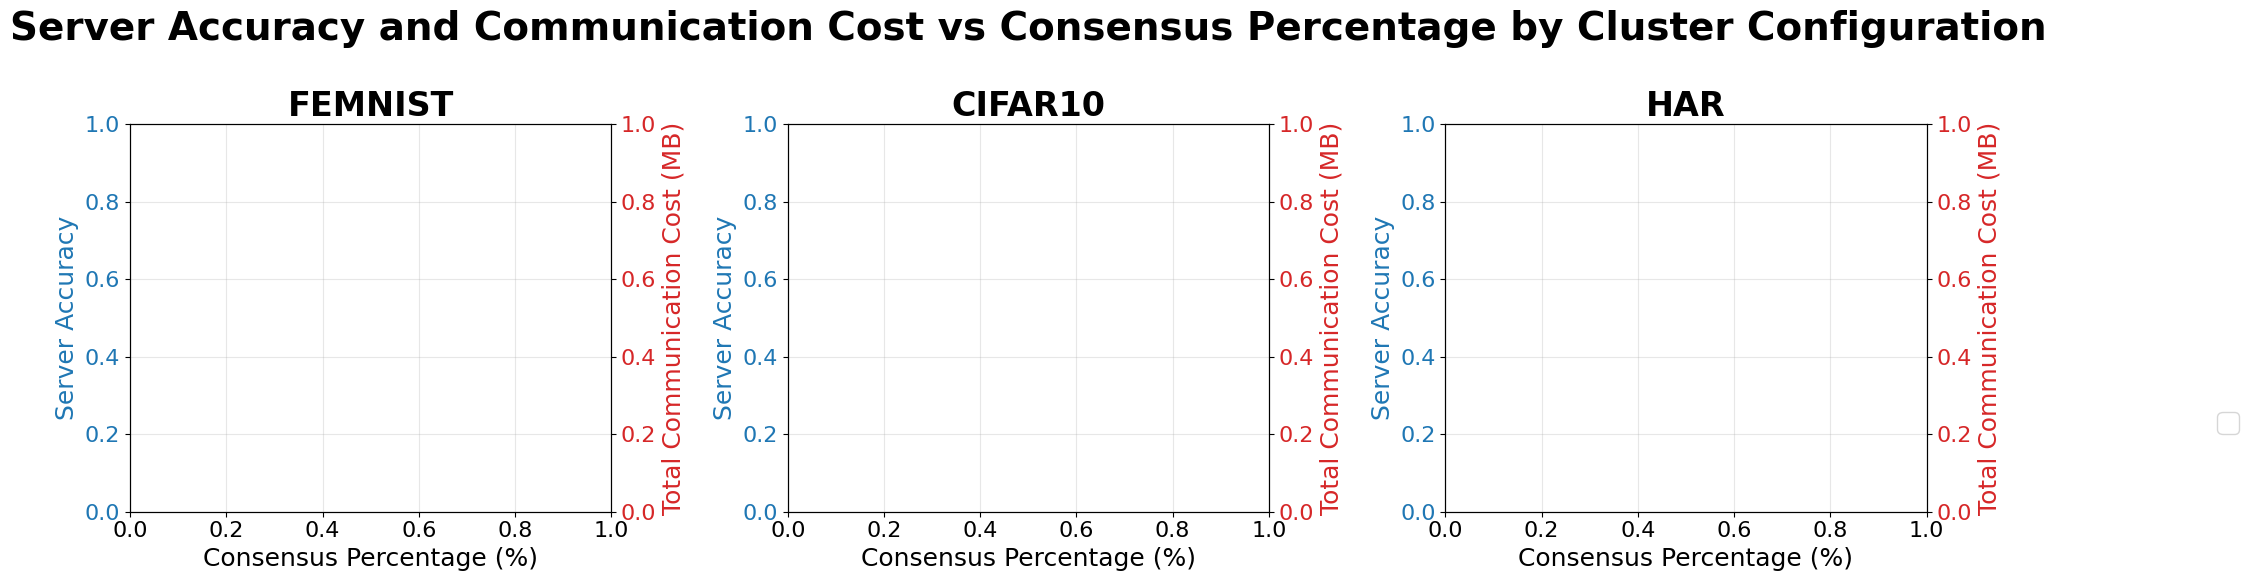


Created 3-subplot figure with shared legend


In [ ]:
# Group runs by cluster size for consensus percentage analysis
# Create figure with 3 subplots (one per dataset)
from collections import defaultdict

# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 17,
        "figure.titlesize": 22,
        "legend.title_fontsize": 17,
    }
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Store all line objects and labels for shared legend
all_lines = []
all_labels = []

for ax_idx, (dataset_name, results_dict) in enumerate(results_by_dataset_rq2.items()):
    ax1 = axes[ax_idx]

    consensus_cluster_runs = defaultdict(list)

    for run_name, data in results_dict.items():
        # Extract cluster size from run name
        # Format: "N-clust-vote-<identifier>" or "N-clusters-<identifier>"
        if "clust" in run_name:
            # Extract N (cluster size)
            parts = run_name.split("-")
            if parts[0].isdigit():
                cluster_size = parts[0]

                # Check if this is a vote run or a regular cluster run
                if "vote" in run_name:
                    # This is a vote run - include it
                    consensus_cluster_runs[cluster_size].append(
                        {
                            "run_name": run_name,
                            "consensus_percentage": data.get("consensus_percentage", 0.5),
                            "server_accuracy": data["server_accuracy"],
                            "total_cost_mb": data["total_cost_mb"],
                            "is_vote": True,
                        }
                    )
                elif "clust" in run_name and data.get("prune_percent") == 0.1:
                    # This is a regular cluster run with prune_percent=0.1
                    consensus_cluster_runs[cluster_size].append(
                        {
                            "run_name": run_name,
                            "consensus_percentage": data.get("consensus_percentage", 0.5),
                            "server_accuracy": data["server_accuracy"],
                            "total_cost_mb": data["total_cost_mb"],
                            "is_vote": False,
                        }
                    )

    # Sort each cluster's runs by consensus_percentage
    for cluster_size in consensus_cluster_runs:
        consensus_cluster_runs[cluster_size].sort(key=lambda x: x["consensus_percentage"])

    # Left y-axis for accuracy
    ax1.set_xlabel("Consensus Percentage (%)", fontsize=18)
    ax1.set_ylabel("Server Accuracy", color="tab:blue", fontsize=18)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Right y-axis for communication cost
    ax2 = ax1.twinx()
    ax2.set_ylabel("Total Communication Cost (MB)", color="tab:red", fontsize=18)
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # Color schemes for different cluster sizes
    accuracy_colors = plt.cm.Blues(np.linspace(0.4, 0.9, max(len(consensus_cluster_runs), 1)))
    cost_colors = plt.cm.Reds(np.linspace(0.4, 0.9, max(len(consensus_cluster_runs), 1)))

    # Plot each cluster size
    for idx, cluster_size in enumerate(sorted(consensus_cluster_runs.keys(), key=int)):
        runs = consensus_cluster_runs[cluster_size]

        if not runs:
            continue

        # Extract data
        consensus_percentages = [r["consensus_percentage"] * 100 for r in runs]
        accuracies = [r["server_accuracy"] for r in runs]
        costs = [r["total_cost_mb"] for r in runs]

        # Plot accuracy on left y-axis
        line1 = ax1.plot(
            consensus_percentages,
            accuracies,
            marker="o",
            linestyle="-",
            color=accuracy_colors[idx],
            label=f"{cluster_size} Clusters (Accuracy)",
            linewidth=2,
        )[0]

        # Plot communication cost on right y-axis
        line2 = ax2.plot(
            consensus_percentages,
            costs,
            marker="s",
            linestyle="--",
            color=cost_colors[idx],
            label=f"{cluster_size} Clusters (Cost)",
            linewidth=2,
        )[0]

        # Collect lines and labels for shared legend (only from first subplot)
        if ax_idx == 0:
            all_lines.extend([line1, line2])
            all_labels.extend([f"{cluster_size} Clusters (Accuracy)", f"{cluster_size} Clusters (Cost)"])

        print(f"\n{dataset_name} - {cluster_size} Clusters: {len(runs)} runs plotted")
        for r in runs:
            print(
                f"  {r['run_name']}: consensus={r['consensus_percentage']}, acc={r['server_accuracy']:.4f}, cost={r['total_cost_mb']:.2f} MB"
            )

    # Add grid
    ax1.grid(True, alpha=0.3)

    # Set subplot title
    ax1.set_title(f"{dataset_name}", fontsize=24, fontweight="bold")

# Create a shared legend below all subplots
fig.legend(all_lines, all_labels, loc="lower center", fontsize=20, bbox_to_anchor=(1.1, 0.25))

# Overall title
fig.suptitle(
    "Server Accuracy and Communication Cost vs Consensus Percentage by Cluster Configuration",
    fontsize=28,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with shared legend")


FEMNIST: Plotted 0 cluster configurations

CIFAR10: Plotted 0 cluster configurations

HAR: Plotted 0 cluster configurations


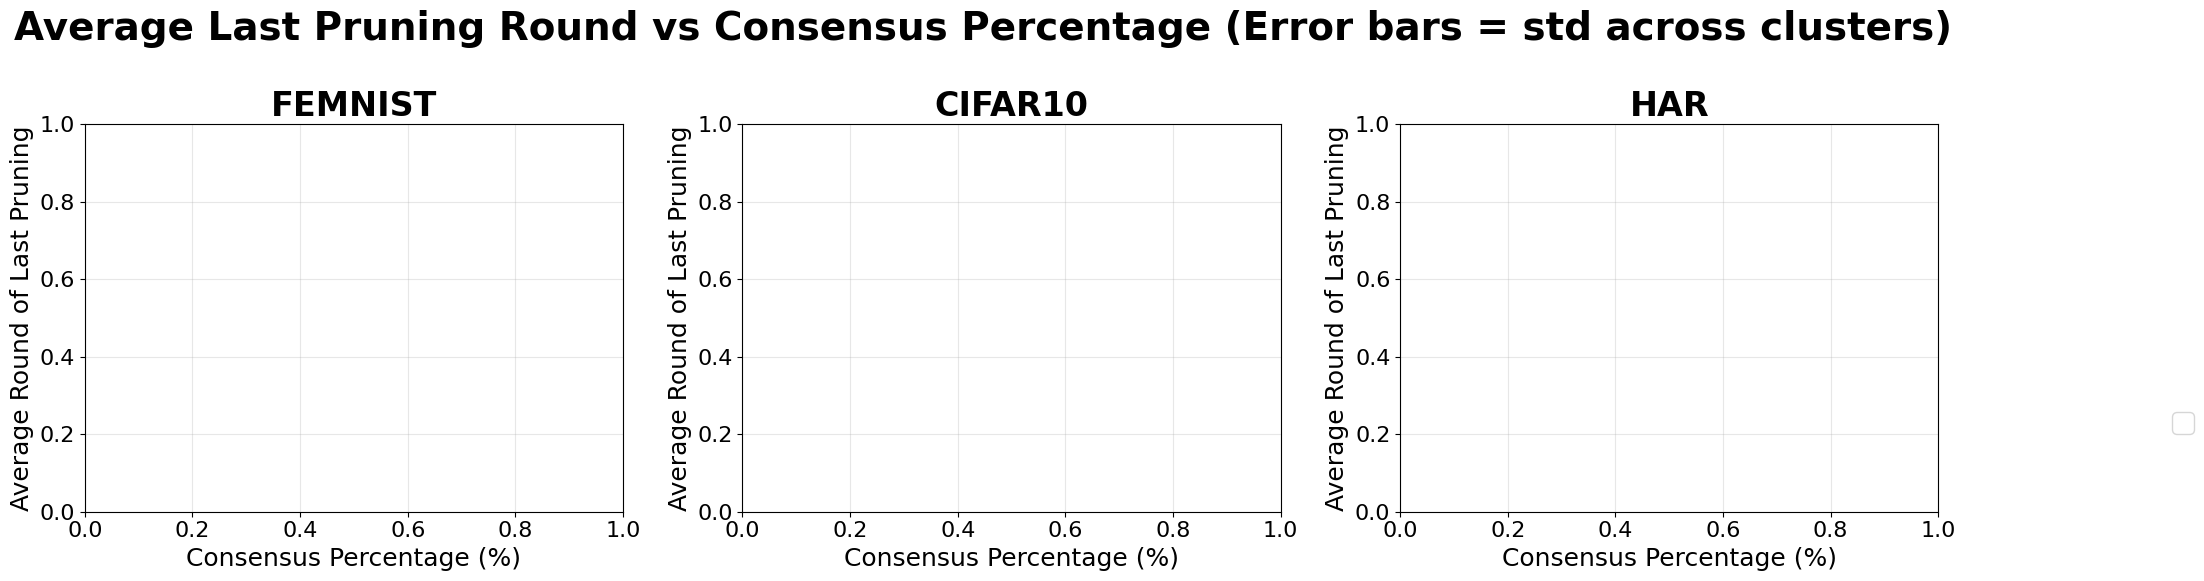


Created 3-subplot figure with shared legend


In [ ]:
# Plot average pruning round vs consensus percentage
# Create figure with 3 subplots (one per dataset)
from collections import defaultdict

# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 17,
        "figure.titlesize": 22,
        "legend.title_fontsize": 17,
    }
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Store all line objects and labels for shared legend
all_lines = []
all_labels = []

for ax_idx, (dataset_name, results_dict) in enumerate(results_by_dataset_rq2.items()):
    ax = axes[ax_idx]

    # Group by (cluster_size, consensus_percentage)
    cluster_size_pruning_data = defaultdict(lambda: defaultdict(list))

    for run_name, data in results_dict.items():
        # Only consider runs with pruning events
        if "pruning_events" in data and data["pruning_events"]:
            consensus_percent = data.get("consensus_percentage", 0.5)

            # Extract cluster size from run name
            # Format: "N-clust-vote-..." or "N-clust-..."
            if "clust" in run_name:
                parts = run_name.split("-")
                if parts[0].isdigit():
                    cluster_size = parts[0]

                    # Find the maximum (last) pruning round for each group in this run
                    group_max_rounds = {}  # {group_id: max_round}
                    for event in data["pruning_events"]:
                        group_id = event["group_id"]
                        round_num = event["round"]

                        if group_id not in group_max_rounds or round_num > group_max_rounds[group_id]:
                            group_max_rounds[group_id] = round_num

                    # Store the last pruning round for each cluster (group)
                    if group_max_rounds:
                        for group_id, last_round in group_max_rounds.items():
                            cluster_size_pruning_data[cluster_size][consensus_percent].append(last_round)

                        print(
                            f"{dataset_name} - {run_name}: cluster_size={cluster_size}, consensus={consensus_percent}, last pruning rounds by group={group_max_rounds}"
                        )

    # Plot each cluster size as a separate line
    for cluster_idx, cluster_size in enumerate(sorted(cluster_size_pruning_data.keys(), key=int)):
        consensus_data = cluster_size_pruning_data[cluster_size]

        consensus_percentages = []
        avg_pruning_rounds = []
        std_pruning_rounds = []

        for consensus_percent in sorted(consensus_data.keys()):
            rounds_list = consensus_data[consensus_percent]

            consensus_percentages.append(consensus_percent * 100)  # Convert to percentage
            avg_pruning_rounds.append(np.mean(rounds_list))
            std_pruning_rounds.append(np.std(rounds_list))

            print(
                f"\n{dataset_name} - {cluster_size} Clusters @ Consensus {consensus_percent * 100}%: {len(rounds_list)} cluster instances"
            )
            print(f"  Average last pruning round: {np.mean(rounds_list):.2f} ± {np.std(rounds_list):.2f}")
            print(f"  Cluster rounds: {rounds_list}")

        # Plot this cluster size with error bars
        line = ax.errorbar(
            consensus_percentages,
            avg_pruning_rounds,
            yerr=std_pruning_rounds,
            marker="o",
            linestyle="-",
            linewidth=2,
            markersize=6,
            capsize=4,
            capthick=1.5,
            label=f"{cluster_size} Clusters",
            alpha=0.8,
        )

        # Collect lines and labels for shared legend (only from first subplot)
        if ax_idx == 0:
            all_lines.append(line)
            all_labels.append(f"{cluster_size} Clusters")

    ax.set_xlabel("Consensus Percentage (%)", fontsize=18)
    ax.set_ylabel("Average Round of Last Pruning", fontsize=18)
    ax.set_title(f"{dataset_name}", fontsize=24, fontweight="bold")
    ax.grid(True, alpha=0.3)

    print(f"\n{dataset_name}: Plotted {len(cluster_size_pruning_data)} cluster configurations")

# Create a shared legend below all subplots
fig.legend(all_lines, all_labels, loc="lower center", fontsize=20, bbox_to_anchor=(1.1, 0.25))

# Overall title
fig.suptitle(
    "Average Last Pruning Round vs Consensus Percentage (Error bars = std across clusters)",
    fontsize=28,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with shared legend")

8-clust-vote-4: cluster_size=8, consensus=0.7, last pruning rounds by group={6: 87, 1: 59, 3: 81, 2: 130, 0: 128, 4: 125, 5: 109}
4-clust-vote-4: cluster_size=4, consensus=0.7, last pruning rounds by group={1: 106, 0: 136, 3: 147, 2: 150}
2-clust-vote-4: cluster_size=2, consensus=0.7, last pruning rounds by group={0: 124, 1: 126}
8-clust-vote-3: cluster_size=8, consensus=0.5, last pruning rounds by group={6: 53, 2: 53, 3: 71, 5: 57, 4: 70, 0: 100, 1: 38}
4-clust-vote-3: cluster_size=4, consensus=0.5, last pruning rounds by group={1: 60, 2: 85, 3: 93, 0: 103}
2-clust-vote-3: cluster_size=2, consensus=0.5, last pruning rounds by group={1: 87, 0: 81}
8-clust-vote-2: cluster_size=8, consensus=0.3, last pruning rounds by group={1: 28, 5: 34, 0: 53, 6: 43, 3: 34, 2: 34, 4: 50}
4-clust-vote-2: cluster_size=4, consensus=0.3, last pruning rounds by group={1: 32, 2: 47, 3: 54, 0: 53}
2-clust-vote-2: cluster_size=2, consensus=0.3, last pruning rounds by group={0: 55, 1: 56}
8-clust-vote-1: cluste

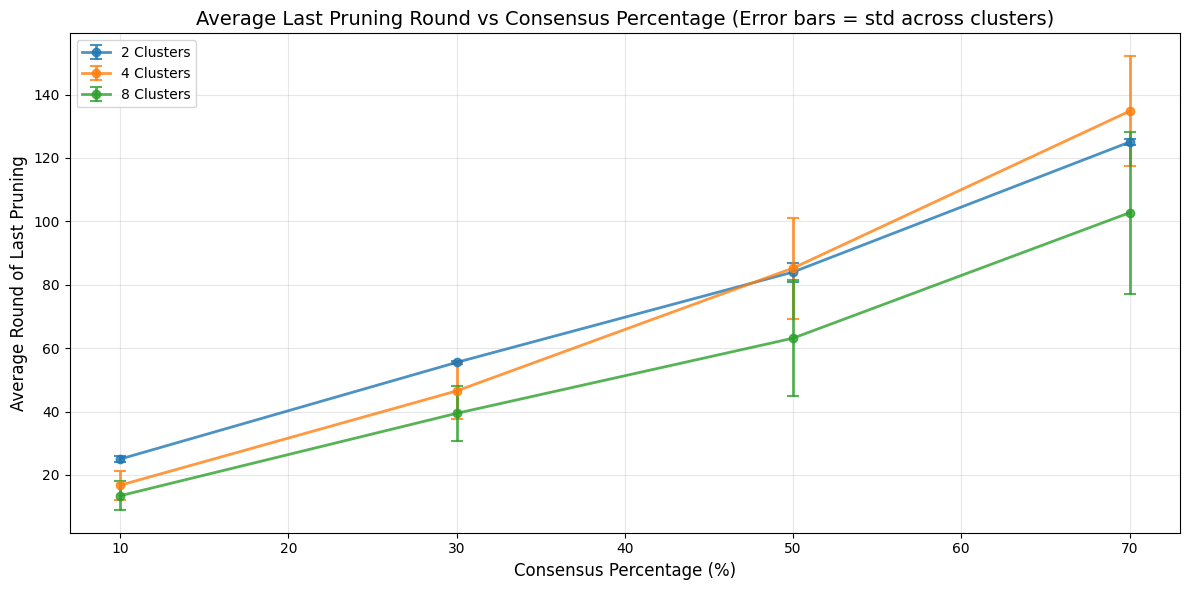


Plotted 3 cluster configurations


In [11]:
# Plot average pruning round vs consensus percentage
# Group by cluster size (same as cell 13), error bars represent variability across clusters
from collections import defaultdict

# Group by (cluster_size, consensus_percentage)
cluster_size_pruning_data = defaultdict(lambda: defaultdict(list))

for run_name, data in results_dict.items():
    # Only consider runs with pruning events
    if "pruning_events" in data and data["pruning_events"]:
        consensus_percent = data.get("consensus_percentage", 0.5)

        # Extract cluster size from run name
        # Format: "N-clust-vote-..." or "N-clust-..."
        if "clust" in run_name:
            parts = run_name.split("-")
            if parts[0].isdigit():
                cluster_size = parts[0]

                # Find the maximum (last) pruning round for each group in this run
                group_max_rounds = {}  # {group_id: max_round}
                for event in data["pruning_events"]:
                    group_id = event["group_id"]
                    round_num = event["round"]

                    if group_id not in group_max_rounds or round_num > group_max_rounds[group_id]:
                        group_max_rounds[group_id] = round_num

                # Store the last pruning round for each cluster (group)
                if group_max_rounds:
                    for group_id, last_round in group_max_rounds.items():
                        cluster_size_pruning_data[cluster_size][consensus_percent].append(last_round)

                    print(
                        f"{run_name}: cluster_size={cluster_size}, consensus={consensus_percent}, last pruning rounds by group={group_max_rounds}"
                    )

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each cluster size as a separate line
for cluster_idx, cluster_size in enumerate(sorted(cluster_size_pruning_data.keys(), key=int)):
    consensus_data = cluster_size_pruning_data[cluster_size]

    consensus_percentages = []
    avg_pruning_rounds = []
    std_pruning_rounds = []

    for consensus_percent in sorted(consensus_data.keys()):
        rounds_list = consensus_data[consensus_percent]

        consensus_percentages.append(consensus_percent * 100)  # Convert to percentage
        avg_pruning_rounds.append(np.mean(rounds_list))
        std_pruning_rounds.append(np.std(rounds_list))

        print(f"\n{cluster_size} Clusters @ Consensus {consensus_percent * 100}%: {len(rounds_list)} cluster instances")
        print(f"  Average last pruning round: {np.mean(rounds_list):.2f} ± {np.std(rounds_list):.2f}")
        print(f"  Cluster rounds: {rounds_list}")

    # Plot this cluster size with error bars
    plt.errorbar(
        consensus_percentages,
        avg_pruning_rounds,
        yerr=std_pruning_rounds,
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6,
        capsize=4,
        capthick=1.5,
        label=f"{cluster_size} Clusters",
        alpha=0.8,
    )

plt.xlabel("Consensus Percentage (%)", fontsize=12)
plt.ylabel("Average Round of Last Pruning", fontsize=12)
plt.title("Average Last Pruning Round vs Consensus Percentage (Error bars = std across clusters)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nPlotted {len(cluster_size_pruning_data)} cluster configurations")


# RQ1 answer

In [ ]:
# Collect metrics from "best" runs with cluster communication cost aggregation
sweep_ids_to_analyze = [
    "ICDCS/FEMNIST/u92g0s0z",
    "ICDCS/FEMNIST/z7tjnjne",
    "ICDCS/FEMNIST/hsfkweiz",
    "ICDCS/FEMNIST/5a5tkdmn",
    "saul0/FEMNIST/7ogcjdbm",
    "ICDCS/FEMNIST/i2r19y2m",
]  # FEMNIST


# sweep_ids_to_analyze = [
#     "ICDCS/FedCIFAR10/g68sgl1c",
#     "ICDCS/FedCIFAR10/c508rqqy",
#     "ICDCS/FedCIFAR10/0op8a4d5",
#     "saul0/FedCIFAR10/mafyqrve",
#     "ICDCS/FedCIFAR10/vuzowa0x",
#     "saul0/FedCIFAR10/db54d3c9",
# ] #CIFAR10

# sweep_ids_to_analyze = [
#     "ICDCS/FedHAR/4tlcvgyv",
#     "saul0/FedHAR/5nf0ajkn",
#     "saul0/FedHAR/62j9vb3j",
#     "ICDCS/FedHAR/djbnmmz3",
#     "ICDCS/FedHAR/dyskhgg5",
#     "ICDCS/FedHAR/dxblr88q",
# ] #HAR


# Define metrics to collect
metrics_to_collect = ["Server/Test/Acc", "Test/Acc", "Personal/Test/Acc"]

# Dictionary to store best run results with cluster cost aggregation
best_runs_with_cluster_cost = {}

print("=" * 80)
print("Collecting metrics from 'best' runs with cluster cost aggregation")
print(f"Metrics to collect: {metrics_to_collect}")
print("=" * 80)

for sweep_id in sweep_ids_to_analyze:
    print(f"\nSweep: {sweep_id}")
    print("-" * 80)

    # Get the sweep
    sweep = api.sweep(sweep_id)
    sweep_runs = sweep.runs

    for run in sweep_runs:
        # Check if "best" is in the run name (case-insensitive)
        if "best" not in run.name.lower():
            continue

        print(f"\nProcessing run: {run.name}")

        # Initialize result dict for this run
        run_metrics = {"sweep_id": sweep_id, "run_name": run.name, "run_id": run.id, "config": run.config}

        # Collect each metric by round
        rounds_data = {}  # {round_num: {metric: value}}

        # For communication cost, we need to sum across all groups
        round_costs = {}  # {round_num: total_cost}

        for row in run.scan_history():
            round_num = row.get("round", None)
            if round_num is None:
                continue

            if round_num not in rounds_data:
                rounds_data[round_num] = {}

            # Collect all requested metrics for this round
            for metric_name in metrics_to_collect:
                val = row.get(metric_name, None)
                if val is not None and val == val:  # Check for not None and not NaN
                    rounds_data[round_num][metric_name] = val

            # Handle communication cost - check for both FedAvg and clustered approaches
            # For FedAvg runs
            if "CommCost/Total/Download" in row:
                val = row.get("CommCost/Total/Download", None)
                if val is not None and val == val:
                    if round_num not in round_costs:
                        round_costs[round_num] = 0
                    round_costs[round_num] += val

            # For clustered runs - sum all group uploads
            if round_num not in round_costs:
                round_costs[round_num] = 0

            for key, val in row.items():
                if "CommCost/Group_" in key and "/Total/Upload" in key:
                    if val is not None and val == val:
                        round_costs[round_num] += val

        # Convert to lists indexed by round
        if rounds_data:
            sorted_rounds = sorted(rounds_data.keys())
            run_metrics["rounds"] = sorted_rounds

            # Store regular metrics
            for metric_name in metrics_to_collect:
                metric_values = [rounds_data[r].get(metric_name, None) for r in sorted_rounds]
                run_metrics[metric_name] = metric_values

                # Print summary
                valid_values = [v for v in metric_values if v is not None]
                if valid_values:
                    print(f"  {metric_name}: {len(valid_values)} values across {len(sorted_rounds)} rounds")
                    print(f"    First: {valid_values[0]:.4f}, Last: {valid_values[-1]:.4f}")
                else:
                    print(f"  {metric_name}: No data found")

            # Store communication cost (sum across all clusters/groups)
            comm_cost_values = [round_costs.get(r, 0) for r in sorted_rounds]

            # Calculate cumulative sum
            cumulative_cost = np.cumsum(comm_cost_values)
            run_metrics["CommCost/Total"] = cumulative_cost.tolist()

            # Convert to MB for display
            comm_cost_mb = [c / (1024 * 1024) for c in cumulative_cost]
            total_cost_mb = comm_cost_mb[-1] if len(comm_cost_mb) > 0 else 0

            print(f"  CommCost/Total: {len(comm_cost_values)} values across {len(sorted_rounds)} rounds")
            print(f"    Total: {total_cost_mb:.2f} MB, Per round avg: {total_cost_mb / len(sorted_rounds):.2f} MB")
        else:
            run_metrics["rounds"] = []
            for metric_name in metrics_to_collect:
                run_metrics[metric_name] = []
            run_metrics["CommCost/Total"] = []
            print("  No round data found")

        # Store in results dictionary
        best_runs_with_cluster_cost[run.name] = run_metrics

print("\n" + "=" * 80)
print(f"Collected metrics from {len(best_runs_with_cluster_cost)} 'best' runs")
print("Results stored in 'best_runs_with_cluster_cost'")
print("Communication cost aggregated across all clusters/groups per round")
print("=" * 80)

Metrics to collect: ['Server/Test/Acc', 'Test/Acc', 'Personal/Test/Acc']

Sweep: ICDCS/FEMNIST/u92g0s0z
--------------------------------------------------------------------------------

Processing run: 4-clust-vote-3-best

Processing run: 4-clust-vote-3-best
  Server/Test/Acc: 21 values across 200 rounds
    First: 0.0541, Last: 0.7809
  Test/Acc: No data found
  Personal/Test/Acc: 21 values across 200 rounds
    First: 0.0476, Last: 0.3580
  CommCost/Total: 200 values across 200 rounds
    Total: 573573.09 MB, Per round avg: 2867.87 MB

Sweep: ICDCS/FEMNIST/z7tjnjne
--------------------------------------------------------------------------------
  Server/Test/Acc: 21 values across 200 rounds
    First: 0.0541, Last: 0.7809
  Test/Acc: No data found
  Personal/Test/Acc: 21 values across 200 rounds
    First: 0.0476, Last: 0.3580
  CommCost/Total: 200 values across 200 rounds
    Total: 573573.09 MB, Per round avg: 2867.87 MB

Sweep: ICDCS/FEMNIST/z7tjnjne
------------------------------

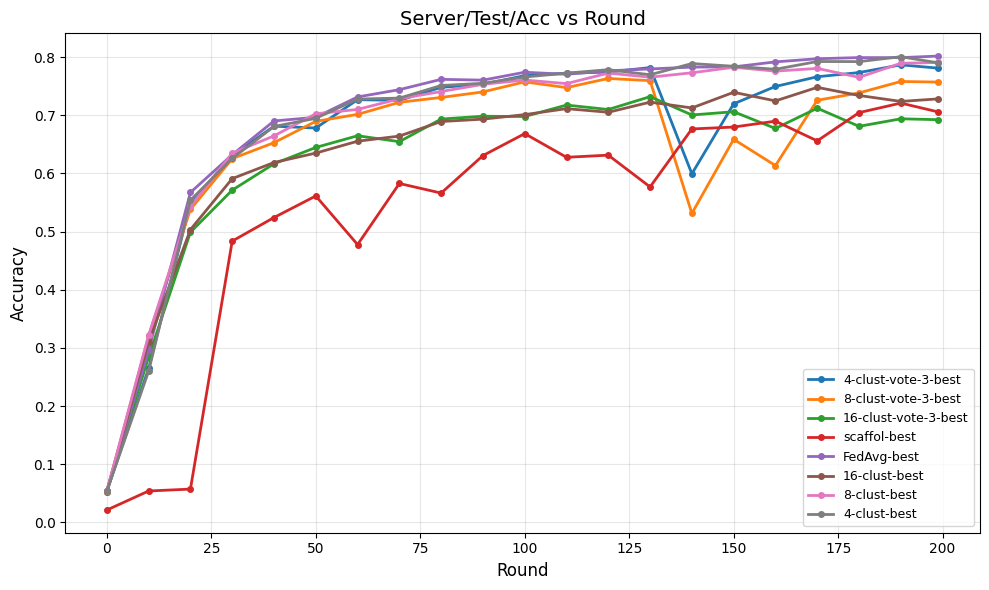

Plotted 8 runs for ['Server/Test/Acc']


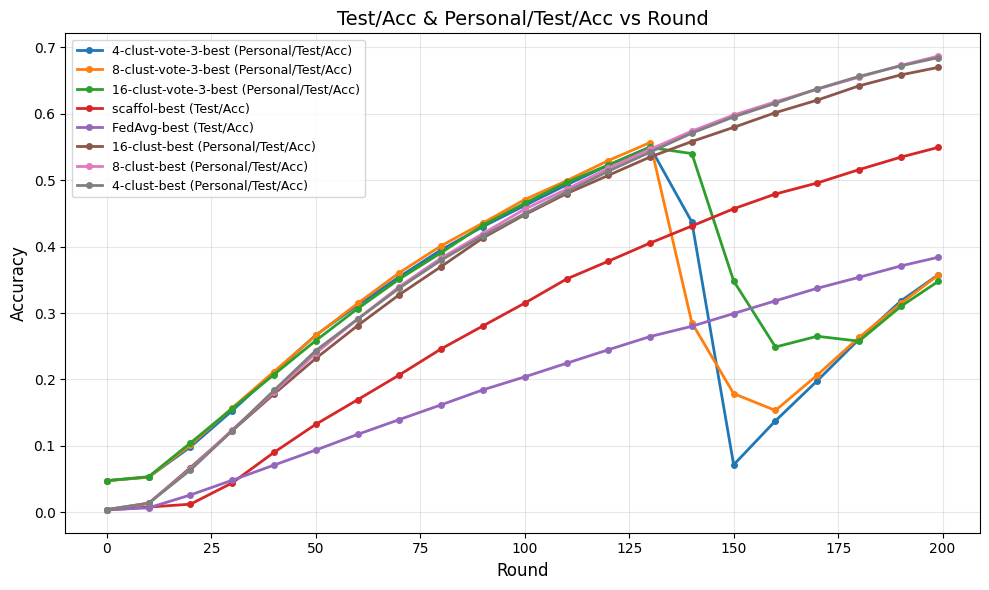

Plotted 8 runs for ['Test/Acc', 'Personal/Test/Acc']


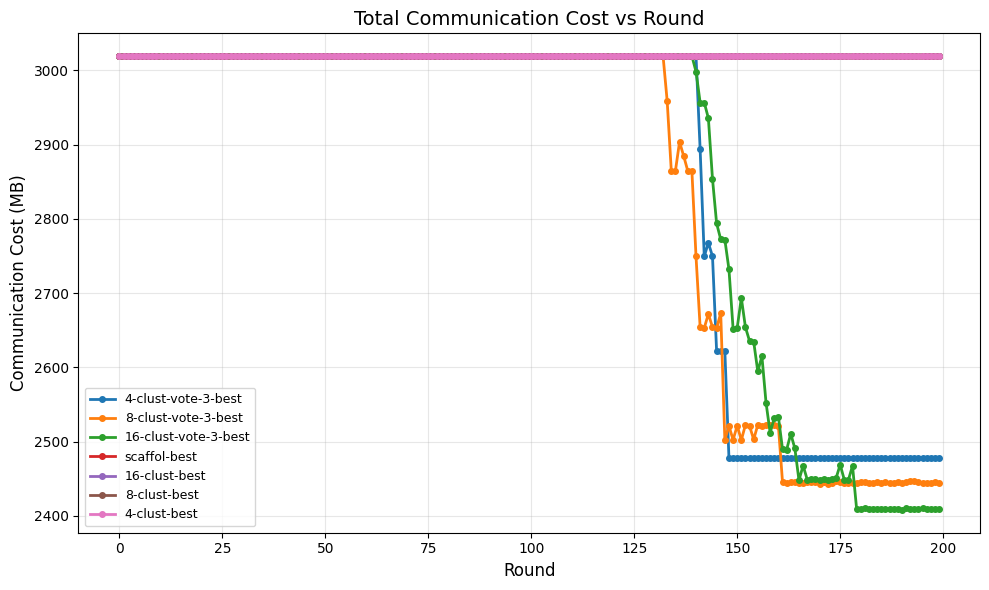

Plotted 7 runs for ['CommCost/Total']


In [ ]:
# Plot metrics from best_runs_with_cluster_cost
# Create separate plots for each metric (Test/Acc and Personal/Test/Acc share the same plot)

metrics_to_plot = ["Server/Test/Acc", ["Test/Acc", "Personal/Test/Acc"], "CommCost/Total"]

for metric_entry in metrics_to_plot:
    plt.figure(figsize=(10, 6))

    # Handle both single metric and list of metrics
    if isinstance(metric_entry, list):
        metrics_for_plot = metric_entry
        plot_title = " & ".join(metrics_for_plot) + " vs Round"
    else:
        metrics_for_plot = [metric_entry]
        plot_title = (
            f"{metric_entry} vs Round" if metric_entry != "CommCost/Total" else "Total Communication Cost vs Round"
        )

    plotted_runs = 0
    for run_name, run_data in best_runs_with_cluster_cost.items():
        rounds = run_data.get("rounds", [])

        # Check if this run has any of the metrics we're plotting
        for metric_name in metrics_for_plot:
            metric_values = run_data.get(metric_name, [])

            # Filter out None values
            valid_data = [(r, v) for r, v in zip(rounds, metric_values) if v is not None]

            if valid_data:
                valid_rounds, valid_values = zip(*valid_data)

                # Convert communication cost to MB for plotting
                if metric_name == "CommCost/Total":
                    valid_values = [v / (1024 * 1024) for v in valid_values if v != 0]

                # Create label with metric name if plotting multiple metrics
                if len(metrics_for_plot) > 1:
                    label = f"{run_name} ({metric_name})"
                else:
                    label = run_name

                if len(valid_values) > 0:
                    plt.plot(valid_rounds, valid_values, marker="o", label=label, linewidth=2, markersize=4)
                    plotted_runs += 1

    if plotted_runs > 0:
        plt.xlabel("Round", fontsize=12)

        if "CommCost/Total" in metrics_for_plot:
            plt.ylabel("Communication Cost (MB)", fontsize=12)
        else:
            plt.ylabel("Accuracy", fontsize=12)

        plt.title(plot_title, fontsize=14)
        plt.legend(loc="best", fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Plotted {plotted_runs} runs for {metrics_for_plot}")
    else:
        print(f"No data to plot for {metrics_for_plot}")
        plt.close()